In [8]:
#import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import cv2
import warnings
import random
warnings.filterwarnings('ignore')

In [9]:

ds1_path = "/kaggle/input/datasets/mohamadabouali1/mri-brain-tumor-dataset-4-class-7023-images/BT-MRI Dataset/BT-MRI Dataset/Training"
ds2_path = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
ds3_path = "/kaggle/input/datasets/sabersakin/brainmri/Datasest Merged 1/Datasest Merged 1"

dataset_paths=np.array([ds1_path,ds2_path,ds3_path])

pituitary=np.array([])
no_tumor=np.array([])
meningioma=np.array([])
glioma=np.array([])

classes=np.array([pituitary,no_tumor,meningioma,glioma])

for ds in dataset_paths:
    count=-1
    for dirs in os.listdir(ds):
        paths=os.path.join(ds,dirs)
        count+=1
        for filename in os.listdir(paths):
            if count==0:
                pituitary=np.append(pituitary,os.path.join(paths,filename))
            elif count==1:
                no_tumor=np.append(no_tumor,os.path.join(paths,filename))
            elif count==2:
                meningioma=np.append(meningioma,os.path.join(paths,filename))
            elif count==3:
                glioma=np.append(glioma,os.path.join(paths,filename))

In [10]:
print(" Glioma:",len(glioma), "\n",
      "Meningioma:",len(meningioma), "\n",
      "Pituitary:",len(pituitary), "\n",
      "No-Tumor:",len(no_tumor), "\n",
     )

 Glioma: 6694 
 Meningioma: 6029 
 Pituitary: 6445 
 No-Tumor: 5495 



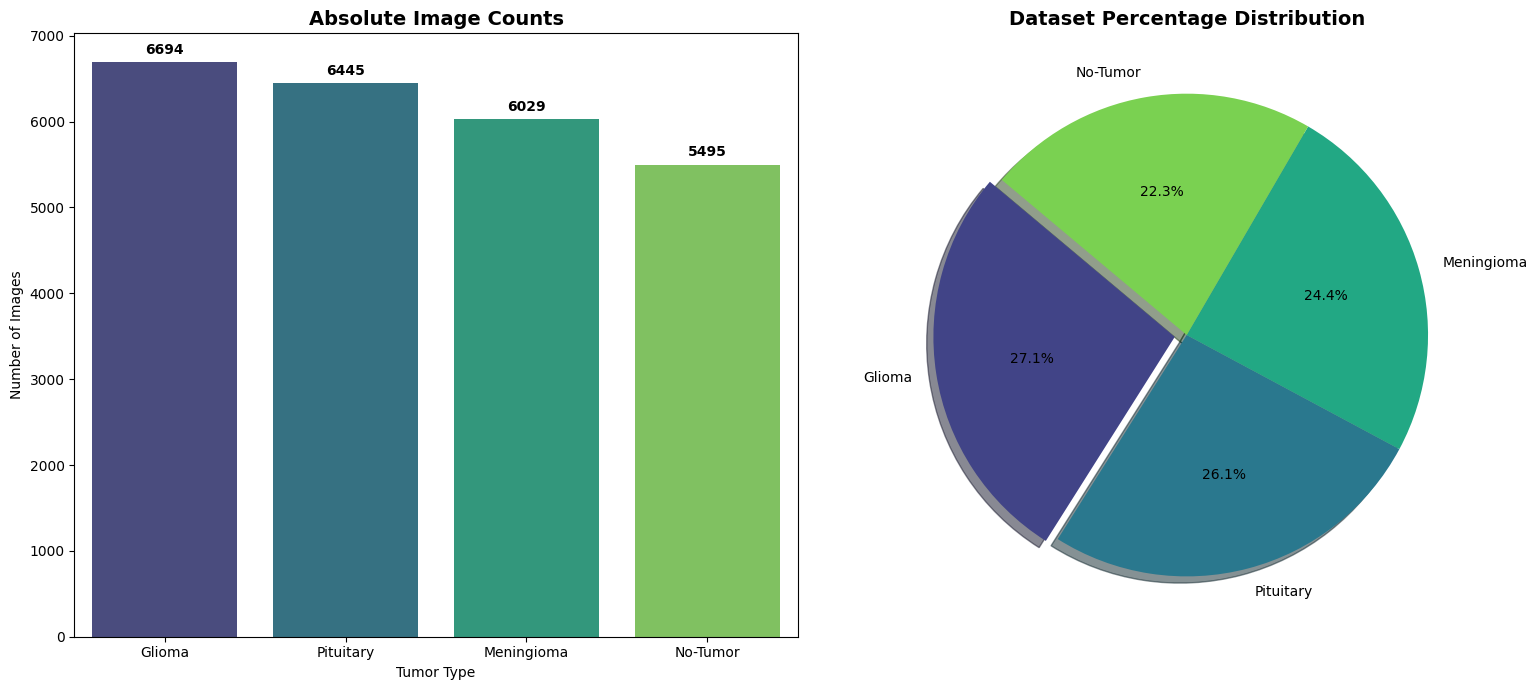

In [11]:
 #Prepare data from your arrays
data = {
    'Tumor Type': ['Glioma', 'Pituitary', 'Meningioma', 'No-Tumor'],
    'Count': [len(glioma), len(pituitary), len(meningioma), len(no_tumor)]
}
df = pd.DataFrame(data).sort_values(by='Count', ascending=False)

# 2. Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Bar Plot ---
sns.barplot(x='Tumor Type', y='Count', data=df, palette='viridis', ax=ax1)
ax1.set_title('Absolute Image Counts', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Images')

# Adding labels to bars
for p in ax1.patches:
    ax1.annotate(format(p.get_height(), '.0f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontweight='bold')

# --- Right: Pie Chart ---
colors = sns.color_palette('viridis', len(df))
ax2.pie(df['Count'], labels=df['Tumor Type'], autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=[0.05, 0, 0, 0], shadow=True)
ax2.set_title('Dataset Percentage Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

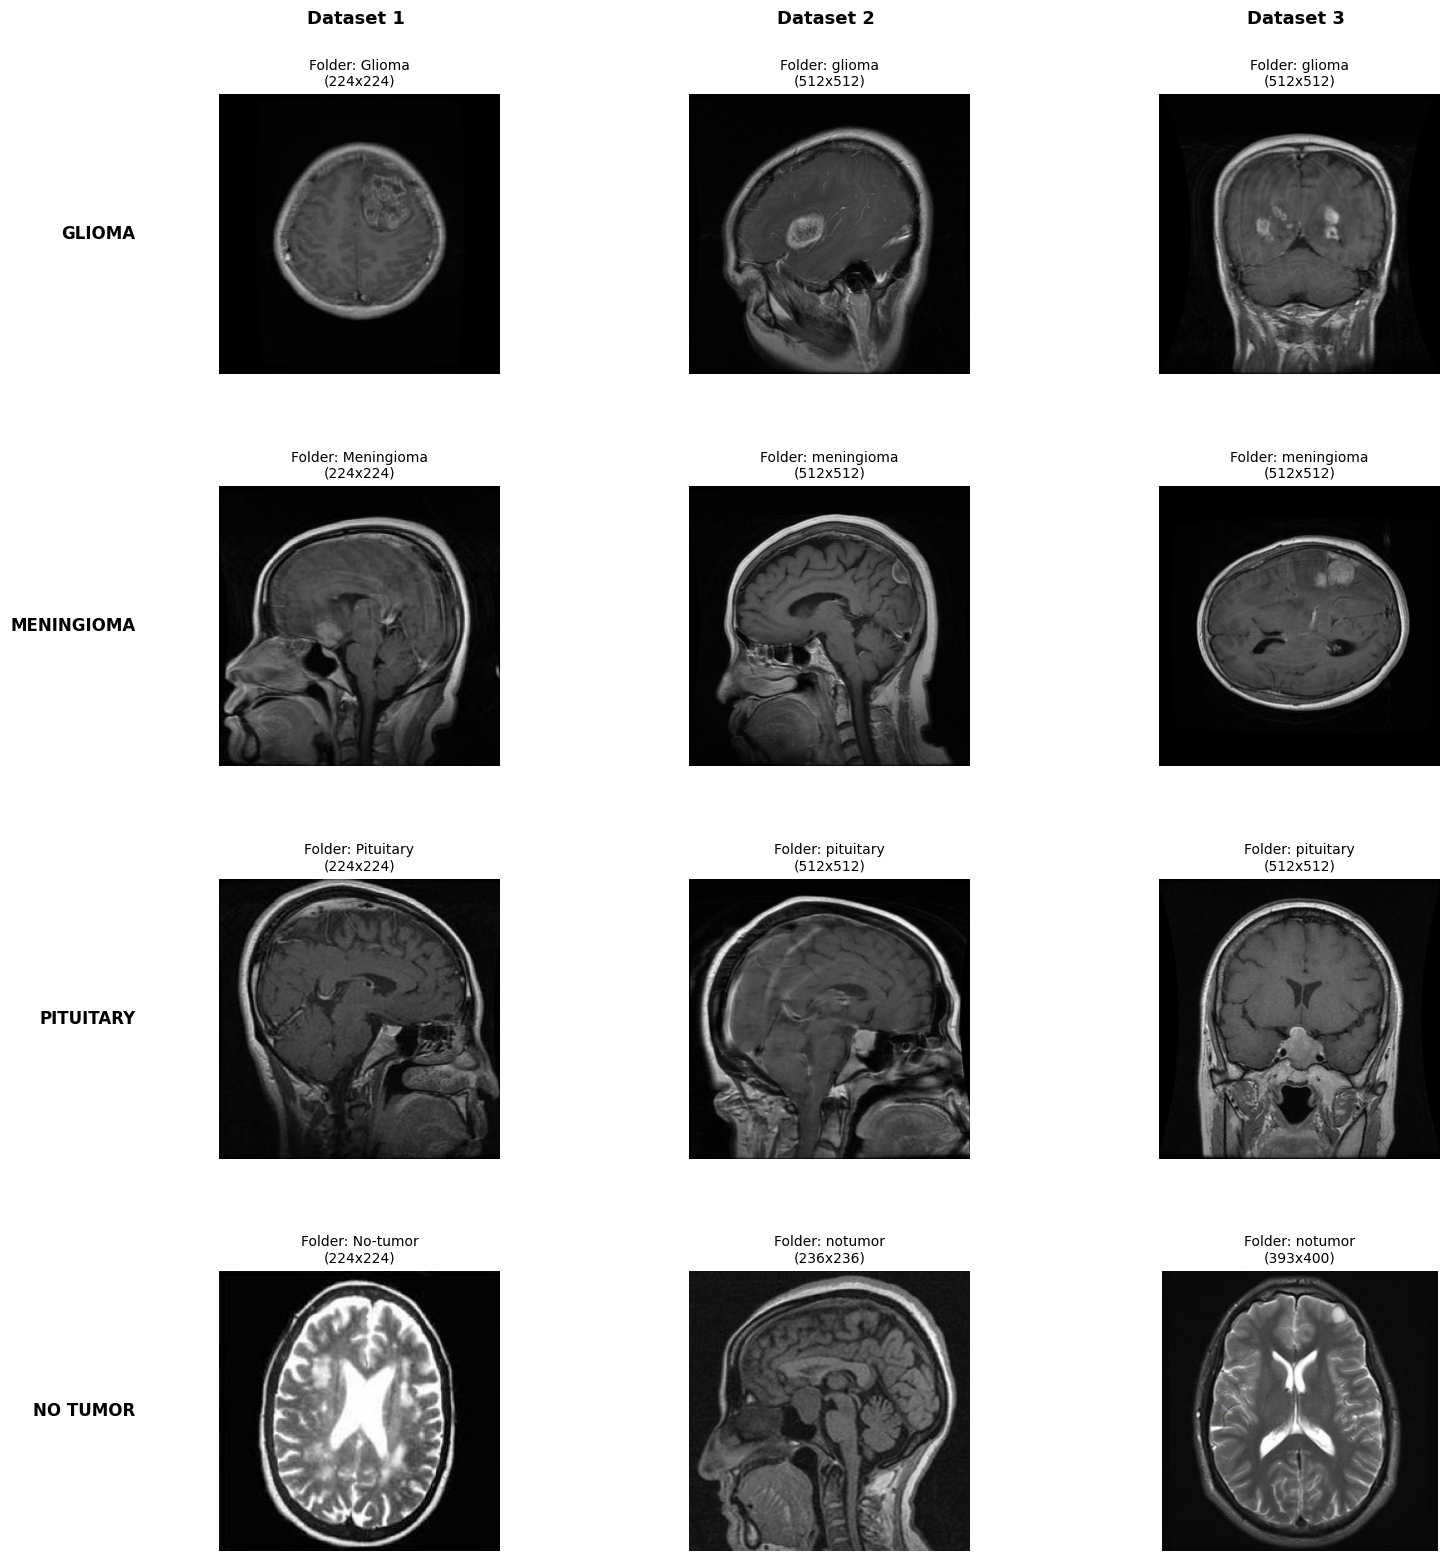

In [12]:
dataset_paths = [ds1_path, ds2_path, ds3_path]
dataset_names = ["Dataset 1 ", "Dataset 2 ", "Dataset 3 "]

# Normalized standard classes we want to map to
standard_classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

# Create a grid: 4 rows (classes) x 3 columns (datasets)
fig, axes = plt.subplots(len(standard_classes), len(dataset_paths), figsize=(15, 16))

# Helper function to find the best folder match regardless of exact naming/case
def find_matching_folder(base_path, target_cls):
    if not os.path.exists(base_path):
        return None
    for folder in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, folder)):
            # Clean names for comparison (lowercase, remove underscores/spaces)
            clean_folder = folder.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            clean_target = target_cls.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            if clean_target in clean_folder or clean_folder in clean_target:
                return folder
    return None

# Loop through columns (datasets) and rows (classes)
for col_idx, path in enumerate(dataset_paths):
    for row_idx, std_cls in enumerate(standard_classes):
        ax = axes[row_idx, col_idx]
        
        # Find the actual folder name in this specific dataset
        matched_folder = find_matching_folder(path, std_cls)
        
        if matched_folder:
            cls_folder = os.path.join(path, matched_folder)
            images = [f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            if images:
                random_img = random.choice(images)
                img_path = os.path.join(cls_folder, random_img)
                
                # Read using OpenCV
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    ax.imshow(img)
                    # Label with the folder name found in that specific dataset + dimensions
                    ax.set_title(f"Folder: {matched_folder}\n({img.shape[1]}x{img.shape[0]})", fontsize=10)
                else:
                    ax.text(0.5, 0.5, "Read Error", ha='center', va='center', color='red')
            else:
                ax.text(0.5, 0.5, "No Images Found", ha='center', va='center', color='orange')
        else:
            ax.text(0.5, 0.5, f"Class Not Found\n({std_cls})", ha='center', va='center', color='red')
            
        ax.axis('off')

# Add Column Titles at the very top of the grid
for col_idx, name in enumerate(dataset_names):
    axes[0, col_idx].text(0.5, 1.25, name, fontsize=13, fontweight='bold', 
                          ha='center', transform=axes[0, col_idx].transAxes)

# Add Row Labels on the far left side
for row_idx, std_cls in enumerate(standard_classes):
    axes[row_idx, 0].text(-0.3, 0.5, std_cls.upper().replace("_", " "), fontsize=12, fontweight='bold',
                          va='center', ha='right', transform=axes[row_idx, 0].transAxes, rotation=0)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.4, wspace=0.3)
plt.show()

This is a new line.

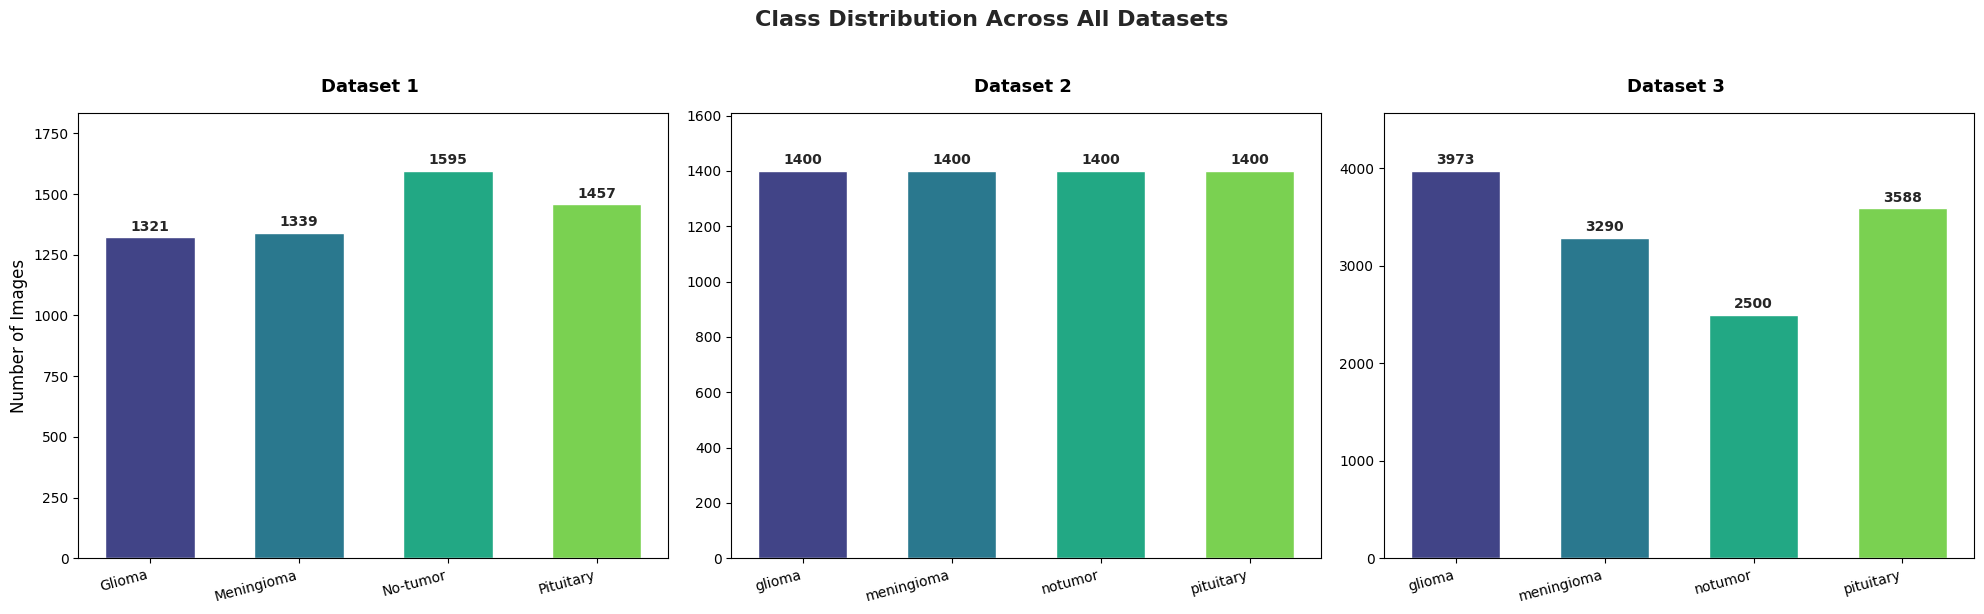

In [13]:
# Set up a 1-row, 3-column plot layout
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)
sns.set_theme(style="whitegrid")

# Loop through each dataset path and plot its distribution
for idx, path in enumerate(dataset_paths):
    class_counts = {}
    
    # 1. Count images per class
    if os.path.exists(path):
        classes = sorted(os.listdir(path))
        for cls in classes:
            cls_folder = os.path.join(path, cls)
            if os.path.isdir(cls_folder):
                count = len([f for f in os.listdir(cls_folder) if not f.startswith('.')])
                class_counts[cls] = count
    else:
        print(f"Warning: Path not found for {dataset_names[idx]}")
        continue

    # 2. Plot on the corresponding subplot axis
    ax = axes[idx]
    if class_counts:
        colors = sns.color_palette("viridis", len(class_counts))
        bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, width=0.6)
        
        # Add values on top of each bar
        for bar in bars:
            yval = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2.0, yval + (max(class_counts.values()) * 0.01), 
                    f'{yval}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
        # Subplot formatting
        ax.set_title(dataset_names[idx], fontsize=13, fontweight='bold', pad=15)
        ax.set_xticklabels(class_counts.keys(), rotation=15, ha='right', fontsize=10)
        ax.set_ylim(0, max(class_counts.values()) * 1.15) # Leave headroom for text labels
        if idx == 0:
            ax.set_ylabel("Number of Images", fontsize=12)
    else:
        ax.text(0.5, 0.5, "No Data Found", ha='center', va='center', fontsize=14)

# Global layout formatting
plt.suptitle("Class Distribution Across All Datasets", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

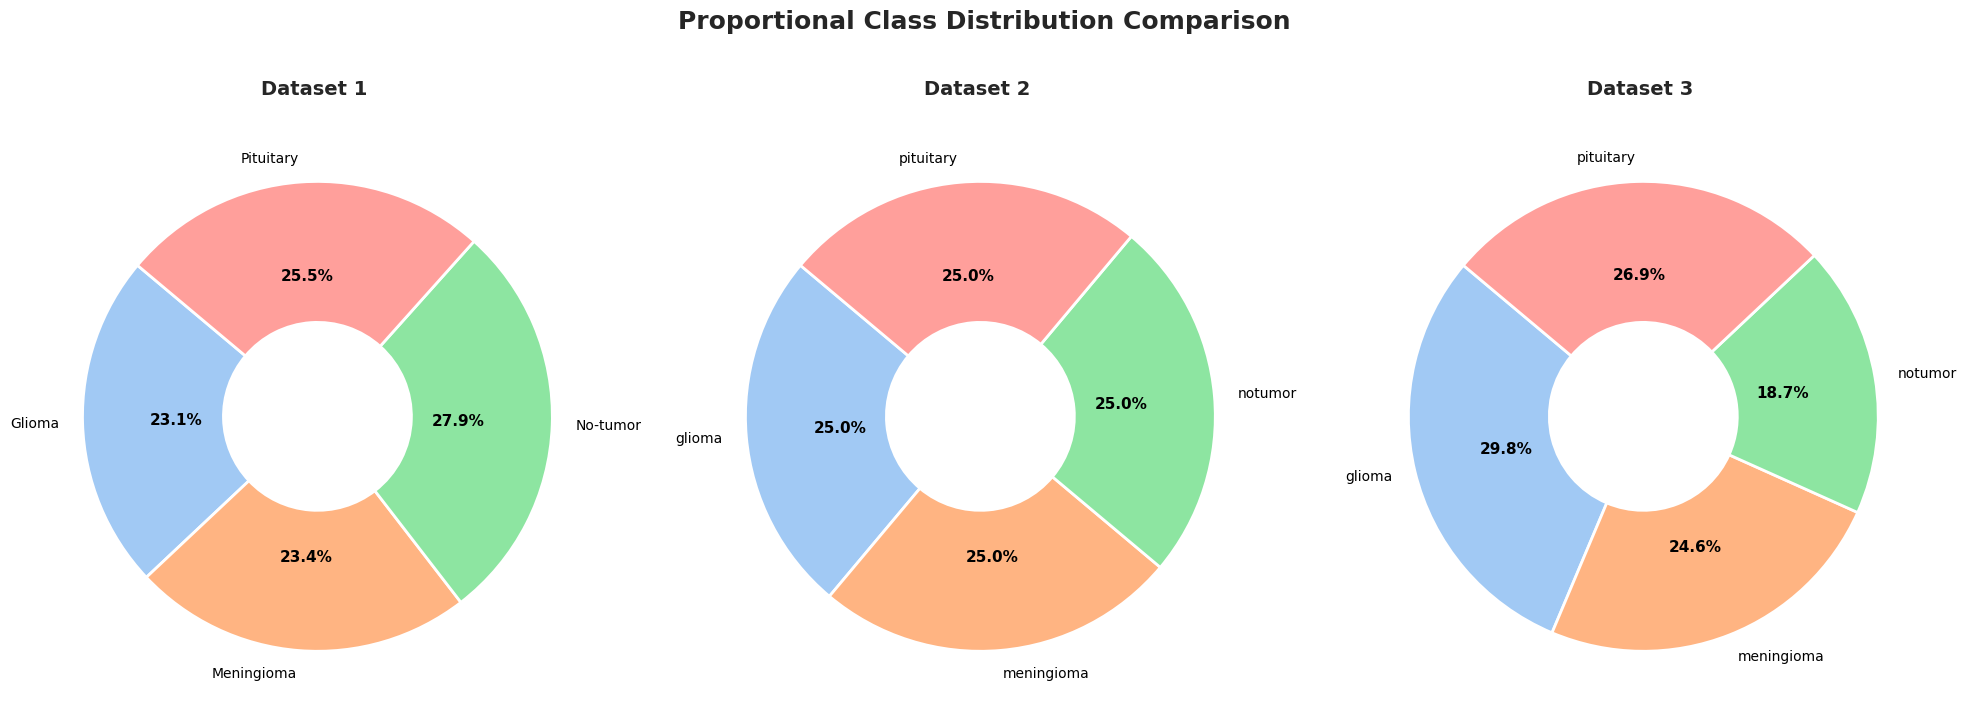

In [14]:
# Set up a 1-row, 3-column plot layout
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.set_theme(style="white")

# Define a consistent color palette for your classes
colors = sns.color_palette("pastel", 4)

for idx, path in enumerate(dataset_paths):
    class_counts = {}
    
    if os.path.exists(path):
        # Gather folder names and file counts
        classes = sorted([c for c in os.listdir(path) if os.path.isdir(os.path.join(path, c))])
        for cls in classes:
            cls_folder = os.path.join(path, cls)
            count = len([f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            if count > 0:
                class_counts[cls] = count
    
    ax = axes[idx]
    
    if class_counts:
        labels = list(class_counts.keys())
        sizes = list(class_counts.values())
        
        # Plot the pie chart
        wedges, texts, autotexts = ax.pie(
            sizes, 
            labels=labels, 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=colors[:len(labels)],
            textprops=dict(color="black", fontsize=10),
            wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2) # Creates a clean donut-style look
        )
        
        # Make the percentage labels bold and easier to read
        for autotext in autotexts:
            autotext.set_fontsize(11)
            autotext.set_weight('bold')
            
        ax.set_title(dataset_names[idx], fontsize=14, fontweight='bold', pad=20)
    else:
        ax.text(0.5, 0.5, f"Data path missing\nor empty", ha='center', va='center', fontsize=12, color='red')
        ax.axis('off')

# Global layout formatting
plt.suptitle("Proportional Class Distribution Comparison", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

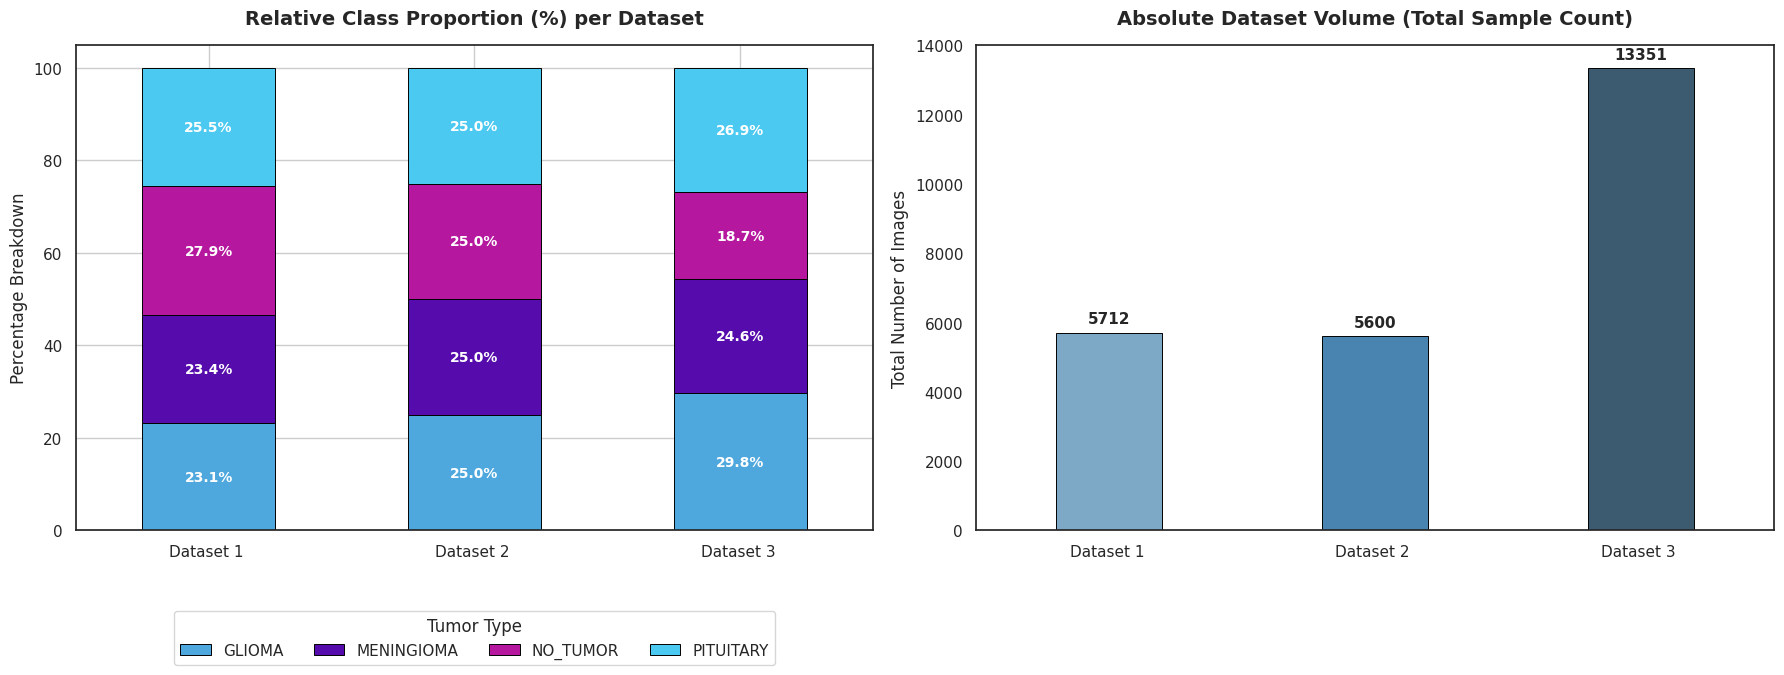

In [15]:
# Normalized mapping to catch slight name variants across datasets
standard_classes = ["glioma", "meningioma", "pituitary", "no_tumor"]

def find_matching_folder(base_path, target_cls):
    if not os.path.exists(base_path): return None
    for folder in os.listdir(base_path):
        if os.path.isdir(os.path.join(base_path, folder)):
            clean_folder = folder.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            clean_target = target_cls.lower().replace("_", "").replace(" ", "").replace("tumor", "")
            if clean_target in clean_folder or clean_folder in clean_target:
                return folder
    return None

# 1. Parse and extract structure into a DataFrame
data_records = []
for name, path in zip(dataset_names, dataset_paths):
    for std_cls in standard_classes:
        matched_folder = find_matching_folder(path, std_cls)
        if matched_folder:
            cls_folder = os.path.join(path, matched_folder)
            count = len([f for f in os.listdir(cls_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            data_records.append({"Dataset": name, "Class": std_cls.upper(), "Count": count})
        else:
            data_records.append({"Dataset": name, "Class": std_cls.upper(), "Count": 0})

df = pd.pivot_table(pd.DataFrame(data_records), values='Count', index='Dataset', columns='Class', aggfunc='sum')
df_percent = df.div(df.sum(axis=1), axis=0) * 100

# 2. Build the Visual Dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.set_theme(style="whitegrid")
colors = ["#4ea8de", "#560bad", "#b5179e", "#4cc9f0"]

# Left Plot: Relative Imbalance (100% Stacked Bar)
df_percent.plot(kind='bar', stacked=True, color=colors, ax=ax1, width=0.5, edgecolor='black', linewidth=0.7)
ax1.set_title("Relative Class Proportion (%) per Dataset", fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel("Percentage Breakdown", fontsize=12)
ax1.set_xlabel("")
ax1.set_xticklabels(df_percent.index, rotation=0, fontsize=11)
ax1.legend(title="Tumor Type", bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, frameon=True)

# Add internal percentage text labels
for p in ax1.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only label slices larger than 5% to keep it clean
        ax1.text(x + width/2, y + height/2, f'{height:.1f}%', 
                 horizontalalignment='center', verticalalignment='center', 
                 color='white', fontweight='bold', fontsize=10)

# Right Plot: Absolute Volume Differences (Total Counts)
df_total = df.sum(axis=1).reset_index(name='Total Images')
sns.barplot(x='Dataset', y='Total Images', data=df_total, ax=ax2, palette="Blues_d", width=0.4, edgecolor='black', linewidth=0.7)
ax2.set_title("Absolute Dataset Volume (Total Sample Count)", fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel("Total Number of Images", fontsize=12)
ax2.set_xlabel("")
ax2.set_xticklabels(df_total['Dataset'], rotation=0, fontsize=11)

# Add values above total volume bars
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

Scanning image resolutions (this might take a minute)...
Scan complete! Analyzed 24663 total images.


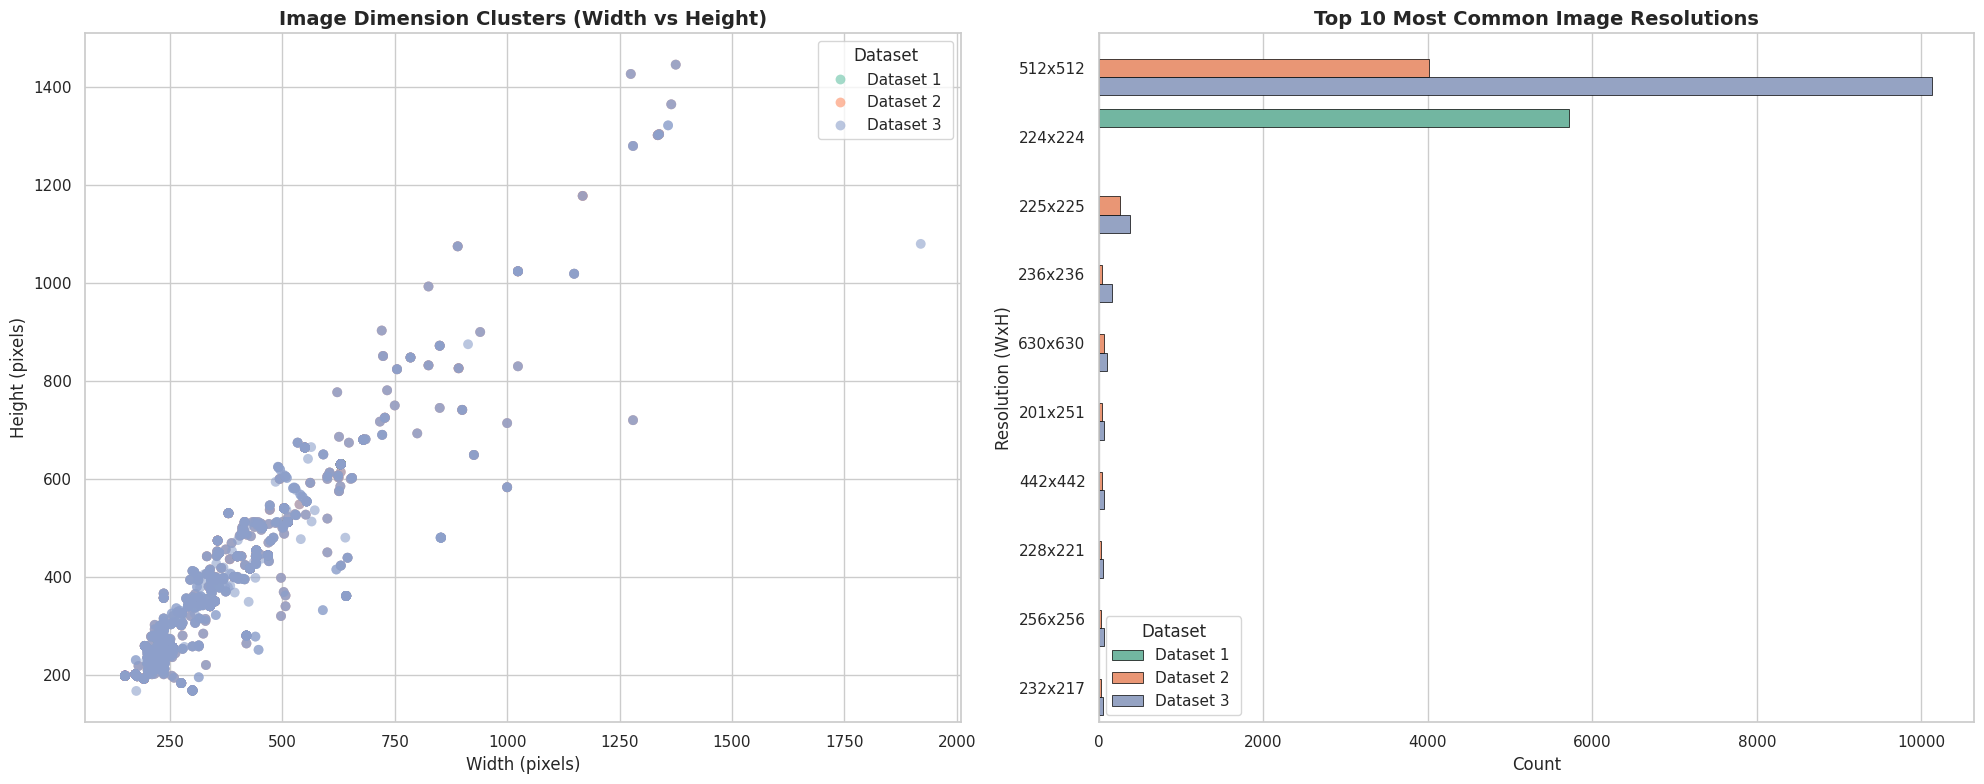

In [16]:
resolution_records = []

print("Scanning image resolutions (this might take a minute)...")

# 1. Walk through datasets and extract width and height
for name, base_path in zip(dataset_names, dataset_paths):
    if not os.path.exists(base_path):
        print(f"Skipping {name}: Path not found.")
        continue
        
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, file)
                
                # Using cv2.imread is reliable, but to speed things up we can just grab shape
                img = cv2.imread(img_path)
                if img is not None:
                    h, w, _ = img.shape
                    resolution_records.append({
                        "Dataset": name,
                        "Width": w,
                        "Height": h,
                        "Resolution": f"{w}x{h}"
                    })

df_res = pd.DataFrame(resolution_records)
print(f"Scan complete! Analyzed {len(df_res)} total images.")

# 2. Build the Dashboard Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.set_theme(style="whitegrid")

# Left Plot: Scatter plot showing Height vs Width clusters
sns.scatterplot(
    data=df_res, 
    x="Width", 
    y="Height", 
    hue="Dataset", 
    alpha=0.6, 
    palette="Set2", 
    ax=ax1,
    s=50,
    edgecolor='none'
)
ax1.set_title("Image Dimension Clusters (Width vs Height)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Width (pixels)", fontsize=12)
ax1.set_ylabel("Height (pixels)", fontsize=12)

# Right Plot: Top 10 resolution configurations across datasets
top_resolutions = df_res['Resolution'].value_counts().nlargest(10).index
df_top_res = df_res[df_res['Resolution'].isin(top_resolutions)]

sns.countplot(
    data=df_top_res, 
    y="Resolution", 
    hue="Dataset", 
    palette="Set2", 
    ax=ax2,
    order=top_resolutions,
    edgecolor='black',
    linewidth=0.5
)
ax2.set_title("Top 10 Most Common Image Resolutions", fontsize=14, fontweight='bold')
ax2.set_xlabel("Count", fontsize=12)
ax2.set_ylabel("Resolution (WxH)", fontsize=12)

plt.tight_layout()
plt.show()